In [1]:
import sys
print(sys.executable)
import numpy as np
print(np.__version__)
print(np.arange(10))


/Users/owenroush/.venvs/dsp/bin/python
2.4.5
[0 1 2 3 4 5 6 7 8 9]


In [2]:
squares = [x**2 for x in range(10)]
evens =  [ x for x in squares if x % 2 == 0 ]
print(squares)
print(evens)


[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
[0, 4, 16, 36, 64]


In [3]:
n = 73
fc = 5000
print(f"Pi to 3 decimals: {np.pi:.3f}")

Pi to 3 decimals: 3.142


In [6]:
def divmod_(a,b):
    return a//b, a%b

quotient, remainder = divmod_(17, 5)
quotient = 10
print( quotient, remainder )

10 2


In [10]:
np.array([1, 2, 3, 4])
np.zeros(10)
np.ones(5)
np.arange(0,10,0.5)
print( np.linspace(0, 1, 10) )

[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


In [11]:
print(quotient)

10


In [12]:
from numpy.fft import fft, fftfreq

In [13]:
x = np.array([1.0,-1.0,1.0,-1.0])
print(fft(x))

[0.+0.j 0.+0.j 4.+0.j 0.+0.j]


In [20]:
x = np.array([np.sin(2*np.pi*x/20) for x in range(20)])
print(fft(x))

[ 4.55531587e-16+0.00000000e+00j -1.43047780e-15-1.00000000e+01j
  3.91921468e-16-8.13897569e-16j -3.44509285e-16+0.00000000e+00j
  2.25388015e-16-6.33530905e-16j  1.63363338e-16+9.51542952e-17j
  1.95413453e-17-3.72501817e-16j  5.60814826e-16+8.88178420e-16j
 -1.46992108e-16-3.91543632e-16j  8.43890151e-17+5.24784678e-17j
 -2.10602227e-16+0.00000000e+00j  3.39873562e-16-5.28086609e-16j
 -1.46992108e-16+3.91543632e-16j  9.29096889e-16-9.40656888e-16j
  1.95413453e-17+3.72501817e-16j  2.70979627e-16-8.77485613e-16j
  2.25388015e-16+6.33530905e-16j -3.58694838e-16-9.51542952e-17j
  3.91921468e-16+8.13897569e-16j -1.43948213e-15+1.00000000e+01j]


In [23]:
fs = 48000
freq = 8000

In [40]:
np.set_printoptions(suppress=True)
np.set_printoptions(suppress=True, precision=4)
x = np.array([np.sin(2 * np.pi * x * freq/fs ) for x in range(24)])
print(fftfreq(len(x), d = 1.0/fs))
print(np.abs(fft(x)))



[     0.    1837.5   3675.    5512.5   7350.    9187.5  11025.   12862.5
  14700.   16537.5  18375.   20212.5 -22050.  -20212.5 -18375.  -16537.5
 -14700.  -12862.5 -11025.   -9187.5  -7350.   -5512.5  -3675.   -1837.5]
[0.8561 0.9527 1.3082 2.3365 9.4555 5.5432 2.3461 1.5815 1.2503 1.0757
 0.9783 0.9279 0.9123 0.9279 0.9783 1.0757 1.2503 1.5815 2.3461 5.5432
 9.4555 2.3365 1.3082 0.9527]


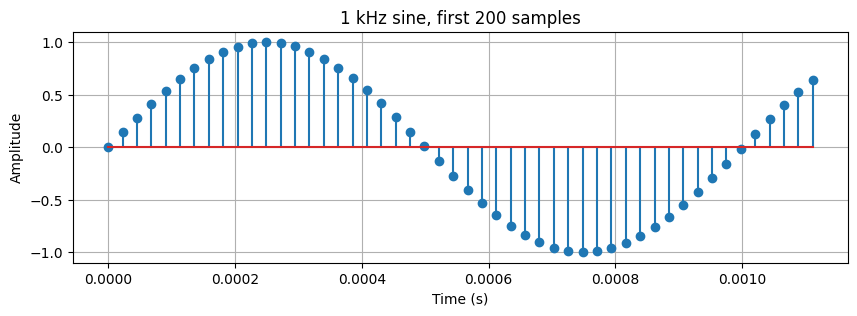

In [55]:
import matplotlib.pyplot as plt
fs = 44100
duration = 0.1
t = np.linspace(0, duration, int(fs * duration), endpoint = False ) 
x = np.array([np.sin(2 * np.pi * 1000 * time ) for time in t ] )
plt.figure(figsize=(10, 3))
plt.stem(t[:50], x[:50])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('1 kHz sine, first 200 samples')
plt.grid(True)
plt.show()

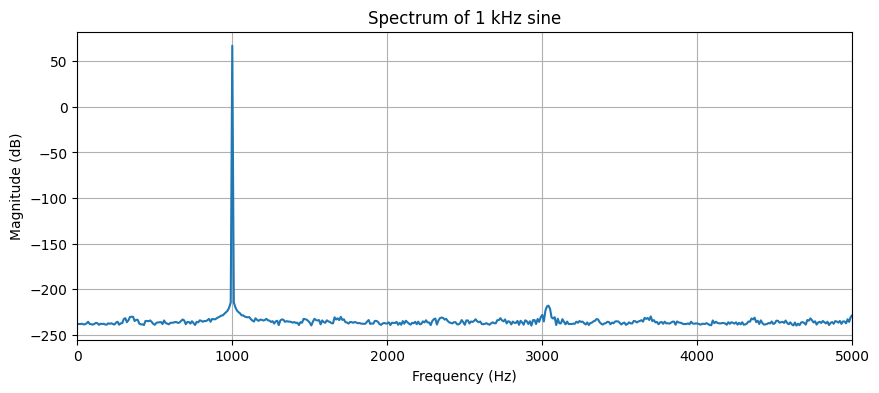

In [46]:
from numpy.fft import fft, fftfreq

X = fft(x)
freqs = fftfreq(len(x), d=1.0/fs)

# Plot magnitude in dB, positive frequencies only
N = len(x) // 2
plt.figure(figsize=(10, 4))
plt.plot(freqs[:N], 20 * np.log10(np.abs(X[:N]) + 1e-12))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Spectrum of 1 kHz sine')
plt.grid(True)
plt.xlim(0, 5000)
plt.show()

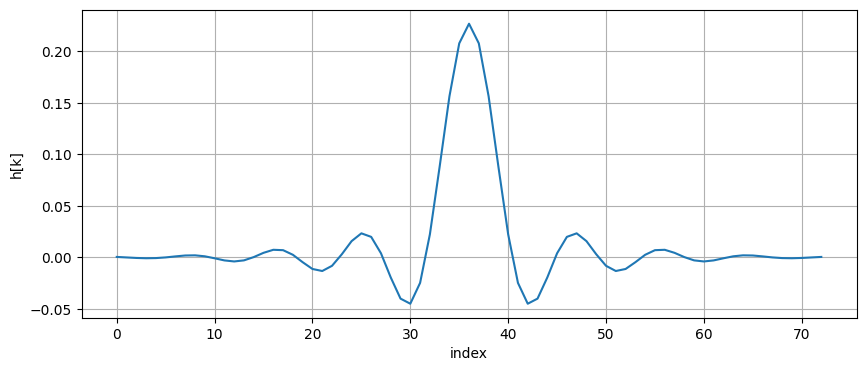

In [75]:
import scipy.signal as signal
fc = 5000
fs = 44100
N = 73
hamming = signal.windows.hamming(N)
hann = signal.windows.hann(N)
n = np.arange(N) - ( N - 1 ) // 2
h_ideal = 2 * fc / fs * np.sinc( n * 2 * fc / fs )
h_coeff = h_ideal * hamming

plt.figure(figsize = (10, 4))
plt.plot( np.arange(0, 73, 1), h_coeffs[:73] )
plt.xlabel( 'index' )
plt.ylabel( 'h[k]' )
plt.grid(True)
plt.show()


Peak stopband ripple: -51.07 dB


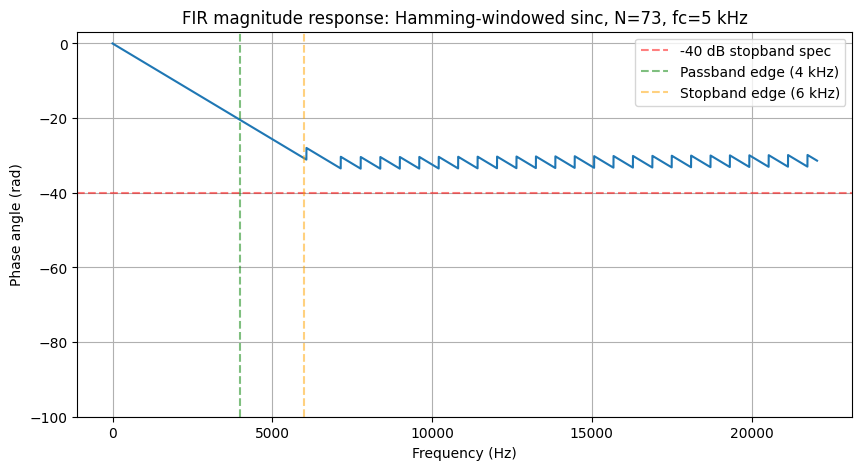

In [89]:
w, H = signal.freqz( h_coeff, worN = 8192, fs = fs )
mask = (w >= 6000)
stopband_response = H[mask]
peak_ripple_db = 20 * np.log10(np.max(np.abs(stopband_response)))
print(f"Peak stopband ripple: {peak_ripple_db:.2f} dB")

plt.figure(figsize = (10, 5))
plt.plot(w, np.unwrap(np.angle(H)))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase angle (rad)')
plt.title('FIR magnitude response: Hamming-windowed sinc, N=73, fc=5 kHz')
plt.grid(True)
plt.axhline(-40, color='red', linestyle='--', alpha=0.5, label='-40 dB stopband spec')
plt.axvline(4000, color='green', linestyle='--', alpha=0.5, label='Passband edge (4 kHz)')
plt.axvline(6000, color='orange', linestyle='--', alpha=0.5, label='Stopband edge (6 kHz)')
plt.legend()
plt.ylim(-100,np.pi )
plt.show()